In [1]:
# Import the FEMSystem Class from directory above
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np


# Solve for A(x,t) given $\rho$

In [2]:
# First load in 2D mesh and 2D modes (statics solution)
pickled_obj = {}

with open('./../2D/allplots/square10sep20num100/results.pkl', 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]
u_left,u_right = 1/jnp.sqrt(2)*(u_even - u_odd), 1/jnp.sqrt(2)* (u_even + u_odd)
u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
theta_at_dofs = pickled_obj["theta_at_dofs"]
n,N,coeffs = pickled_obj["n"],pickled_obj["parameters"]["N"],pickled_obj["coeffs"]

# Get the mesh
mesh = femsystem.mesh

# Print number of degrees of freedom
print(f"Number of degrees of freedom: {femsystem.dofs}")

# Print number of elements
print(f"Number of elements: {femsystem.elements}")

Number of degrees of freedom: 3881
Number of elements: 1914


## Helmholtz Solver

Solving: 

$\nabla \times \nabla \times A + (a + b \langle \Psi^\dagger \Psi \rangle) A = j$

Where

$a = - \frac{\omega_d^2}{\bar{c}^2}$

$b = \frac{1}{\kappa^2}\frac{\overline{Area}}{N}$

a_coeff, b_coeff: -0.0 8.0


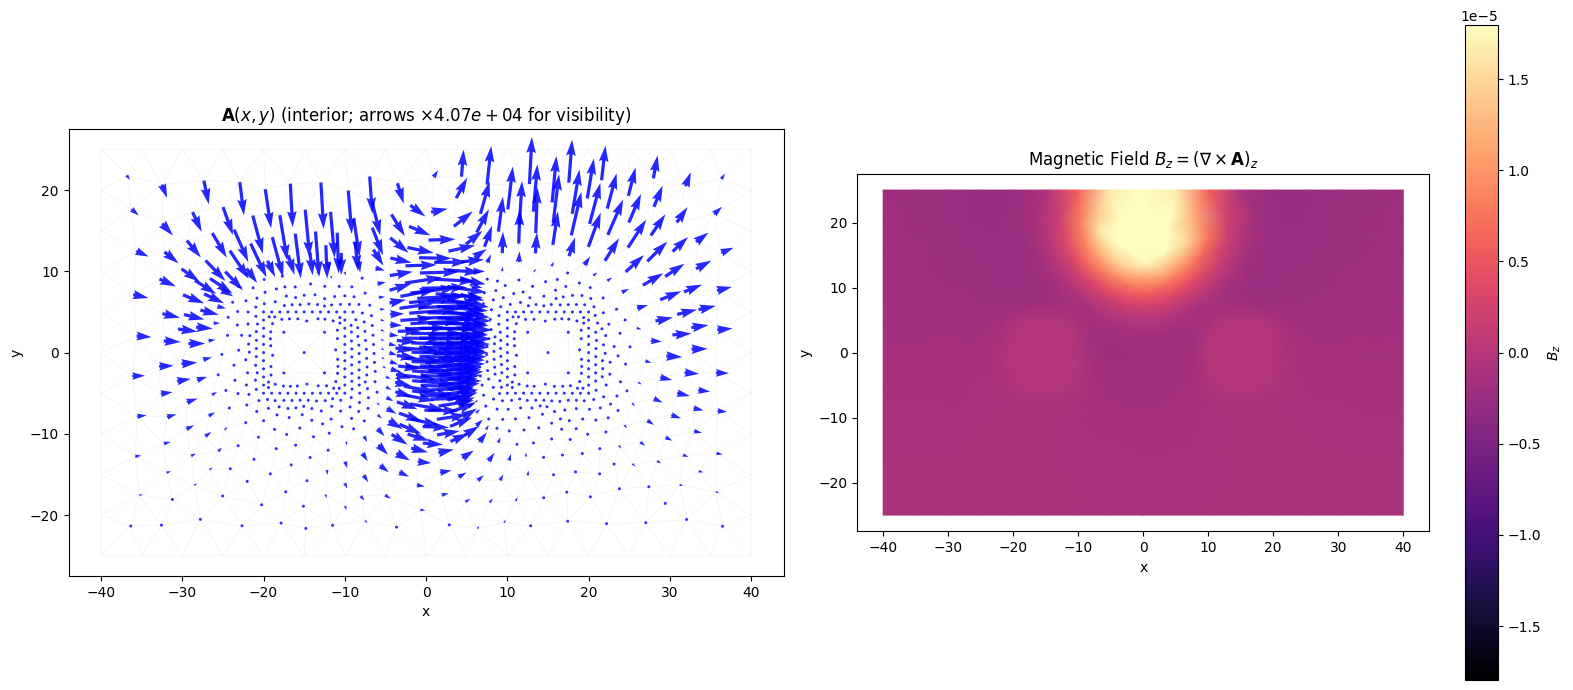

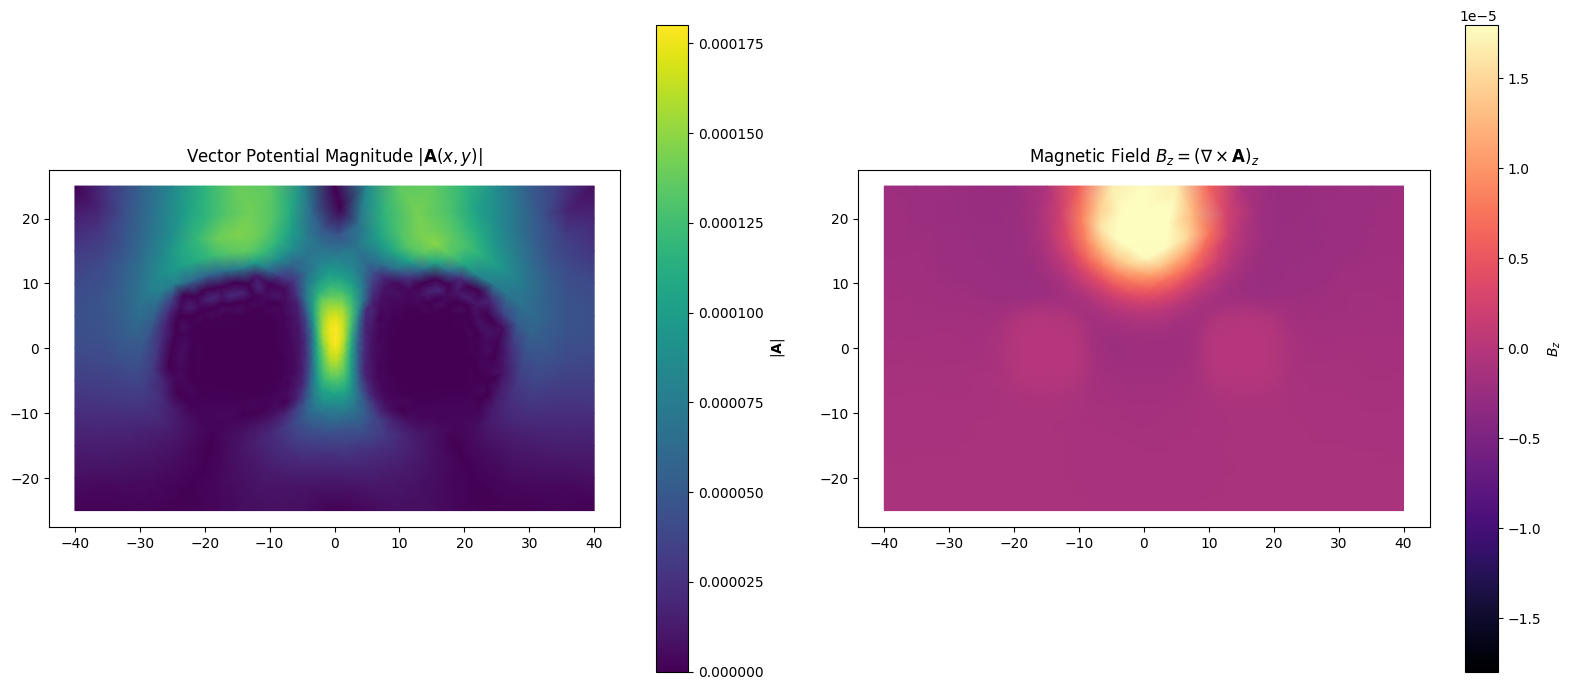

(<Figure size 1600x700 with 4 Axes>,
 array([<Axes: title={'center': 'Vector Potential Magnitude $|\\mathbf{A}(x,y)|$'}>,
        <Axes: title={'center': 'Magnetic Field $B_z = (\\nabla \\times \\mathbf{A})_z$'}>],
       dtype=object))

In [6]:
from scipy.sparse.linalg import spsolve
from skfem import MeshTri, ElementTriN1, ElementTriN2, ElementTriP1, ElementTriP2, Basis, BilinearForm, LinearForm, asm, condense
from skfem.helpers import curl, dot



omega_d = 0
c_bar = 137.036
kappa = 1
area = 800
N_area = 100  # only for b_coeff; do not confuse with pickled particle count

a_coeff = - (omega_d/c_bar)**2
b_coeff = 1/(kappa**2) * area / N_area
print("a_coeff, b_coeff:", a_coeff, b_coeff)

########################################################
# Solver Below
########################################################

nodal_element = femsystem.element  # Get the scikit-fem element used for nodal basis (e.g., ElementTriP1/P2)
nedelic_element = ElementTriN1()
# Same intorder as pickled FEMSystem (often 5 in 2DTwoModesOpt). Otherwise asm(...) rejects
# femsystem.basis.interpolate(psi_exp): quadrature must match basis_edge.
basis_nodal = Basis(mesh, nodal_element, intorder=femsystem.intorder)
basis_edge = Basis(mesh, nedelic_element, intorder=femsystem.intorder)

nodes_x = mesh.p[0]
nodes_y = mesh.p[1]
epsilon = 1e-4
psi_exp = (u_left **2 + u_right**2) * N / 2 + epsilon
# Interpolate psi_exp with femsystem.basis: same FE space as u_* (often P2) and same quadrature
# as basis_edge via intorder above. Using basis_nodal.interpolate(psi_exp) fails (wrong N or wrong quads).

# Strip current on the left (like the working "Initial Test" cell), not a point delta — fills the domain with B.
# On MeshTri2, mesh.p includes midside nodes; P1 nodal DOFs are basis_nodal.N == mesh.nvertices in the *vertex* sense.
# Search closest dof in basis_nodal.doflocs and size b_* with basis_nodal.N so interpolate() agrees.
source_coord = (0.0, 30.0)
source_coord_arr = np.array(source_coord).reshape(2, 1)
dof_xy = basis_nodal.doflocs
closest_node_index = int(np.argmin(np.sum((dof_xy - source_coord_arr) ** 2, axis=0)))
b_nodal_values = np.zeros((2, basis_nodal.N))
b_nodal_values[1, closest_node_index] = 1.0

@BilinearForm
def bilinear_form(u,v,w):
    # / N_area keeps London term O(1) with psi_exp (same balance as your earlier working runs)
    second_term_coeff = a_coeff + b_coeff * w['psi_exp'] / N_area * 100
    return curl(u) * curl(v) + second_term_coeff * dot(u, v)

@LinearForm
def general_source(v, w):
    b_vec = np.array([w['bx'], w['by']])
    return dot(b_vec, v)

@LinearForm
def dipole_source(v, w):
    x = w.x[0]
    y = w.x[1]
    x0, y0 = 0.0, 20.0
    sigma = 10.0
    m = 0.01
    M = (m / (np.pi * sigma**2)) * np.exp(-((x - x0)**2 + (y - y0)**2) / sigma**2)
    Jx = -M * 2 * (y - y0) / sigma**2
    Jy =  M * 2 * (x - x0) / sigma**2
    J_vec = np.array([Jx, Jy])
    return dot(J_vec, v)

A_matrix = asm(bilinear_form, basis_edge,
               psi_exp=femsystem.basis.interpolate(np.asarray(psi_exp, dtype=np.float64)))

b_vector = asm(general_source, basis_edge,
               bx=basis_nodal.interpolate(b_nodal_values[0,:]),
               by=basis_nodal.interpolate(b_nodal_values[1,:]))

b_vector = asm(dipole_source, basis_edge)

A_sol = np.zeros(basis_edge.N)
D = basis_edge.get_dofs().all()
A_int, b_int, x_int, I = condense(A_matrix, b_vector, D=D)
A_sol[I] = spsolve(A_int, b_int)

vis = VisualizeVF(mesh, basis_edge, A_sol)
fig, ax = vis.visualize_vf(A_sol, bz_symmetric_percentile=99.0)
vis.visualize_vf_mag(A_sol, bz_symmetric_percentile=99.0)
# vis.visualize_bz_surface(A_sol, bz_symmetric_percentile=99.0)

# Widget Visualization

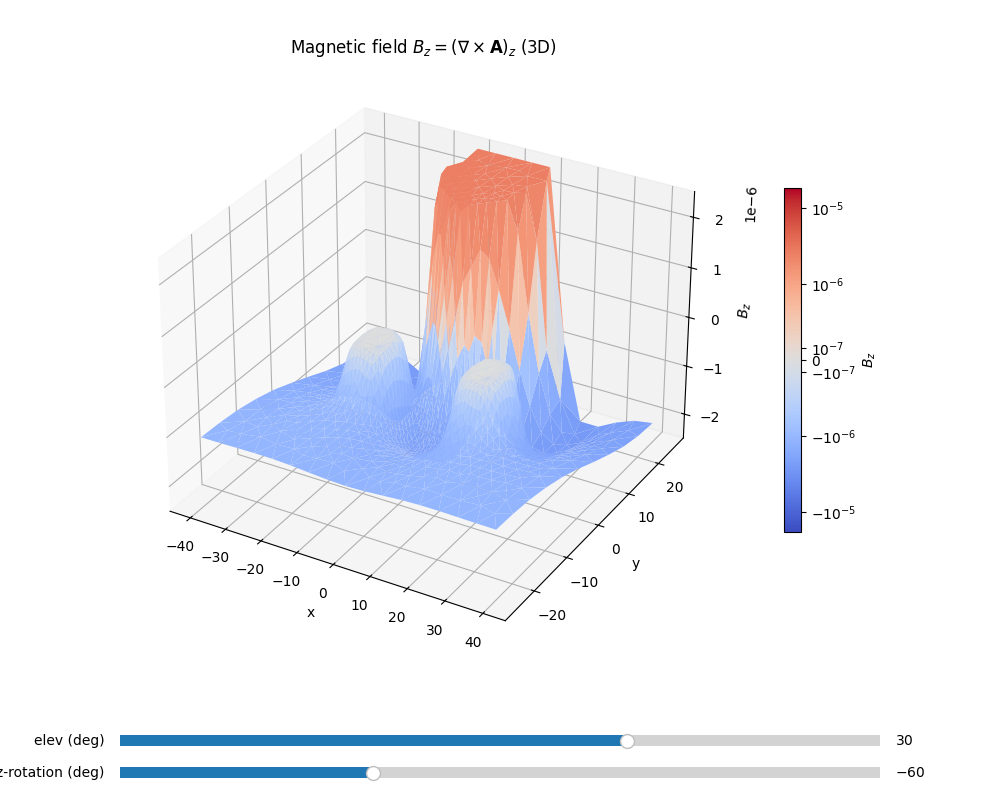

(<Figure size 1000x800 with 4 Axes>,
 <Axes3D: title={'center': 'Magnetic field $B_z = (\\nabla \\times \\mathbf{A})_z$ (3D)'}, xlabel='x', ylabel='y', zlabel='$B_z$'>)

In [7]:
%matplotlib widget
vis.visualize_bz_surface(A_sol, bz_symmetric_percentile=99.0)

# Initial Test Below

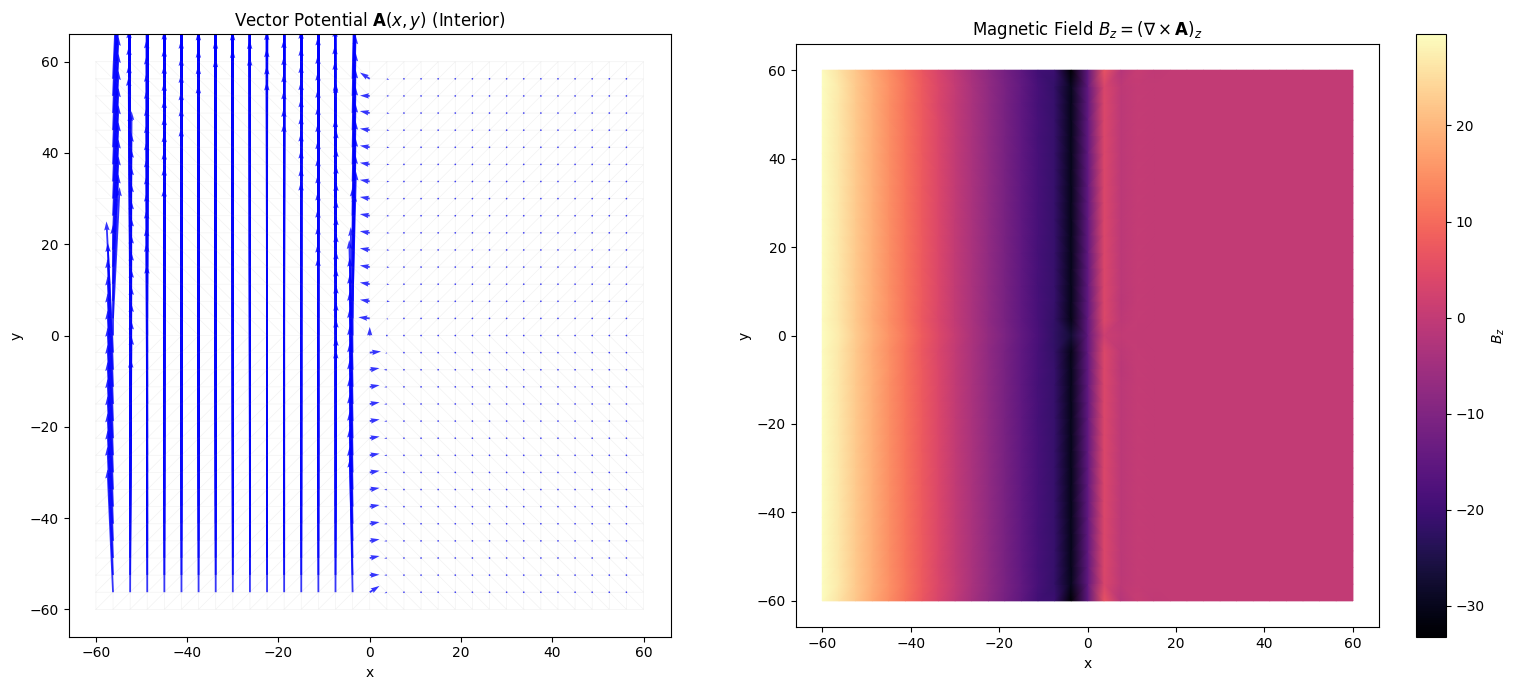

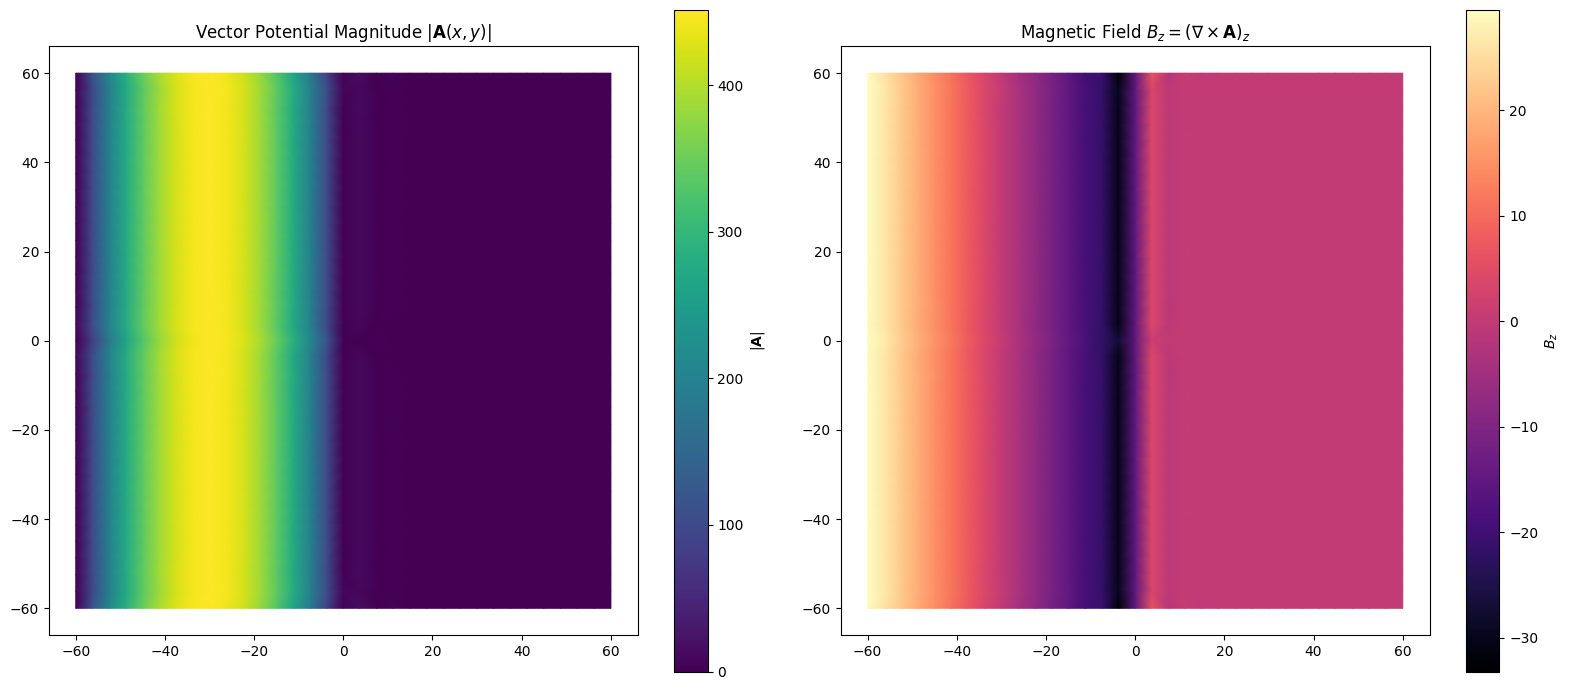

(<Figure size 1600x700 with 4 Axes>,
 array([<Axes: title={'center': 'Vector Potential Magnitude $|\\mathbf{A}(x,y)|$'}>,
        <Axes: title={'center': 'Magnetic Field $B_z = (\\nabla \\times \\mathbf{A})_z$'}>],
       dtype=object))

In [ ]:
from scipy.sparse.linalg import spsolve
from skfem import MeshTri, ElementTriN1, ElementTriP1, Basis, BilinearForm, LinearForm, asm, condense
from skfem.helpers import curl, dot

nodal_element = ElementTriP1()
nedelic_element = ElementTriN1()
basis_nodal = Basis(mesh, nodal_element, intorder=femsystem.intorder)
basis_edge = Basis(mesh, nedelic_element, intorder=femsystem.intorder)

# Simply add in filler a and b (length basis_nodal.N — P1 vertices, not len(mesh.p) on MeshTri2)
nodes_x = basis_nodal.doflocs[0]
epsilon = 1e-8
a_nodal_values = np.where(nodes_x > 0.5, 100.0, epsilon)

b_nodal_values = np.zeros((2, basis_nodal.N))
b_nodal_values[1, :] = 1.0 * (nodes_x < 0.2)  # strip source

@BilinearForm
def bilinear_form(u,v,w):
    # w['a_field'] is a scalar interpolated to the quadratures
    return curl(u) * curl(v) + w['a_field'] * dot(u, v)

@LinearForm
def general_source(v, w):
    # w['b_field'] picks off column of two elements, both scalars interpolated to the quadatures
    b_vec = np.array([w['bx'], w['by']])
    
    # dot() takes the inner product of the source vector and the test function vector 'v'
    return dot(b_vec, v)

A_matrix = asm(bilinear_form, basis_edge, 
               a_field=basis_nodal.interpolate(a_nodal_values))

b_vector = asm(general_source, basis_edge, 
               bx=basis_nodal.interpolate(b_nodal_values[0,:]),
               by=basis_nodal.interpolate(b_nodal_values[1,:]))

# SOLVE
# Enforce tangential A = 0 on boundaries
A_sol = np.zeros(basis_edge.N) # simply a vector of zeros, length of DOFs (nedelic elements)
D = basis_edge.get_dofs().all() # get the boundary indices
A_int, b_int, x_int, I = condense(A_matrix, b_vector, D=D) # condense matrices, I is indices of the interior DOFs
A_sol[I] = spsolve(A_int, b_int) # solve and put into interior only


# VISUALIZE
vis = VisualizeVF(mesh,basis_edge,A_sol)
fig, ax = vis.visualize_vf(A_sol)
vis.visualize_vf_mag(A_sol)

# Calculations for charge density

In [5]:
# Returns array where at index i, it is the true charge imbalance of the coefficient at the ith index
# Remember, length of the coeffs array is n, so will represent a maximum charge imbalance of n-1.
# convention for charge imbalance is defined by Right - Left i think??
def true_charge_imbalances(n):
    if n % 2 == 1:  # odd
        center = n // 2
        return [2 * (center - i) for i in range(n)]
    else:  # even
        center_right = n // 2
        return [2 * (center_right - i) - 1 for i in range(n)]

charge_imbalance_labels = true_charge_imbalances(len(coeffs))

# For finite N, what I want labels that tell me how much is on left, how much is on right
# N is total number of particles, n is total domain of 
half_charge_imbalance = (n-1)/2 - jnp.arange(n) # from (n-1)/2 to -(n-1)/2
num_left = N/2 + half_charge_imbalance
num_right = N/2 - half_charge_imbalance

# Normalize coeffs:
coeffs = coeffs / jnp.sqrt(jnp.sum(jnp.abs(coeffs)**2))
print(jnp.sum(jnp.abs(coeffs)**2))

exp_val_left = jnp.sum(num_left * coeffs**2)
exp_val_right = jnp.sum(num_right * coeffs**2)

# For a symmetric set of coefficients, this should be exactly N/2 for both
print(exp_val_left,exp_val_right,N/2)

0.99999994
35.0 35.0 35.0
